In [14]:
import pandas as pd
import numpy as np
import os
from datetime import datetime

# 文件路径配置
file_path = "D:\\BA-Business Analytics\\Modules\\Advanced Topics in Analytics\\Individual -3.27\\Individual Assignment Data File Electronic_sales.xlsx"

# 检查文件是否存在
if not os.path.exists(file_path):
    print(f"错误：文件不存在，请检查路径：\n{file_path}")
    print("请确认：")
    print("1. 文件名称是否完整（包括扩展名.xlsx）")
    print("2. 文件夹路径是否正确")
    print("3. 文件是否被移动或重命名")
else:
    try:
        # 读取Excel文件
        print("正在读取文件...")
        df = pd.read_excel(file_path)
        print("文件读取成功")
    except Exception as e:
        print(f"读取文件失败：{e}")

正在读取文件...
文件读取成功


In [15]:
# ==================== 1. 数据概览 ====================
print("\n" + "="*60)
print("【数据概览】")
print("="*60)
print(f"数据形状（行数, 列数）: {df.shape}")
print(f"总记录数: {len(df):,} 条")
print(f"总字段数: {len(df.columns)} 个")
        
# ==================== 2. 前5行数据（HEAD） ====================
print("\n" + "="*60)
print("【前5行数据 - HEAD】")
print("="*60)
print(df.head().to_string())
    
# ==================== 3. 字段基本信息 ====================
print("\n" + "="*60)
print("【字段基本信息】")
print("="*60)

# 创建字段信息汇总表
field_info = []
for col in df.columns:
    # 数据类型
    dtype = df[col].dtype
    
    # 非空值数量
    non_null = df[col].count()
    
    # 空值数量
    null_count = df[col].isnull().sum()
    
    # 空值比例
    null_pct = (null_count / len(df)) * 100
    
    # 唯一值数量
    unique_count = df[col].nunique()
    
    # 样本数据（前2个非空值）
    sample_data = df[col].dropna().iloc[:2].tolist() if non_null > 0 else []
    sample_str = str(sample_data)[:50] + "..." if len(str(sample_data)) > 50 else str(sample_data)
    
    field_info.append({
        '字段名': col,
        '数据类型': dtype,
        '非空数': f"{non_null:,}",
        '空值数': f"{null_count:,}",
        '空值比例%': round(null_pct, 2),
        '唯一值数': f"{unique_count:,}",
        '样本数据': sample_str
    })

 # 输出字段信息表格
info_df = pd.DataFrame(field_info)
print(info_df.to_string(index=False))


【数据概览】
数据形状（行数, 列数）: (20000, 16)
总记录数: 20,000 条
总字段数: 16 个

【前5行数据 - HEAD】
   Customer ID  Age Gender Loyalty Member Product Type      SKU  Rating Order Status Payment Method  Total Price  Unit Price  Quantity Purchase Date Shipping Type              Add-ons Purchased  Add-on Total
0         1000   53   Male             No   Smartphone  SKU1004       2    Cancelled    Credit Card      5538.33      791.19         7    2024-03-20      Standard  Accessory,Accessory,Accessory         40.21
1         1000   53   Male             No       Tablet  SKU1002       3    Completed         Paypal       741.09      247.03         3    2024-04-20     Overnight                   Impulse Item         26.09
2         1002   41   Male             No       Laptop  SKU1005       3    Completed    Credit Card      1855.84      463.96         4    2023-10-17       Express                            NaN          0.00
3         1002   41   Male            Yes   Smartphone  SKU1004       2    Completed        

In [16]:
        # ==================== 4. 数值型字段统计 ====================
        print("\n" + "="*60)
        print("【Numeric field descriptive statistics】")
        print("="*60)
        
        # 选择数值型字段
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if numeric_cols:
            print("\nList of numeric fields：", numeric_cols)
            print("\nDescriptive statistics：")
            print(df[numeric_cols].describe().round(2).to_string())
        else:
            print("None numeric fields")
        
        # ==================== 5. 类别型字段统计 ====================
        print("\n" + "="*60)
        print("【Statistics on categorical/text fields】")
        print("="*60)
        
        # 选择非数值型字段
        categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
        if categorical_cols:
            print("\nList of text fields：", categorical_cols)
            print("\nNumber of unique values ​​in each field：")
            for col in categorical_cols:
                print(f"  - {col}: {df[col].nunique():,} 个唯一值")
                
                # 对于唯一值数量适中的字段，显示前5个最常见的值
                if df[col].nunique() <= 20 and df[col].nunique() > 0:
                    print(f"    Common value distribution：")
                    value_counts = df[col].value_counts().head(5)
                    for val, cnt in value_counts.items():
                        pct = (cnt / len(df)) * 100
                        print(f"      {val}: {cnt:,} 条 ({pct:.1f}%)")
        else:
            print("No text fields")


【Numeric field descriptive statistics】

List of numeric fields： ['Customer ID', 'Age', 'Rating', 'Total Price', 'Unit Price', 'Quantity', 'Add-on Total']

Descriptive statistics：
       Customer ID       Age    Rating  Total Price  Unit Price  Quantity  Add-on Total
count     20000.00  20000.00  20000.00     20000.00    20000.00  20000.00      20000.00
mean      10483.53     48.99      3.09      3180.13      578.63      5.49         62.24
std        5631.73     18.04      1.22      2544.98      312.27      2.87         58.06
min        1000.00     18.00      1.00        20.75       20.75      1.00          0.00
25%        5478.00     33.00      2.00      1139.68      361.18      3.00          7.62
50%       10499.50     49.00      3.00      2534.49      463.96      5.00         51.70
75%       15504.00     65.00      4.00      4639.60      791.19      8.00         93.84
max       19998.00     80.00      5.00     11396.80     1139.68     10.00        292.77

【Statistics on categorical/

In [17]:
        # ==================== 6. 日期字段检查 ====================
        print("\n" + "="*60)
        print("【日期字段识别】")
        print("="*60)
        
        # 检查可能包含日期的字段名
        date_keywords = ['date', 'time', 'purchase', 'order', '日', '期']
        potential_date_cols = [col for col in df.columns if any(keyword in col.lower() for keyword in date_keywords)]
        
        if potential_date_cols:
            print("可能的日期字段：", potential_date_cols)
            for col in potential_date_cols:
                try:
                    # 尝试转换为日期类型
                    pd.to_datetime(df[col], errors='raise')
                    print(f"  ✓ {col}: 可以转换为日期格式")
                    # 显示日期范围
                    date_series = pd.to_datetime(df[col], errors='coerce')
                    print(f"    日期范围: {date_series.min()} 至 {date_series.max()}")
                except:
                    print(f"  ✗ {col}: 不是标准的日期格式")
        else:
            print("未识别到明显的日期字段")


【日期字段识别】
可能的日期字段： ['Order Status', 'Purchase Date', 'Add-ons Purchased']
  ✗ Order Status: 不是标准的日期格式
  ✓ Purchase Date: 可以转换为日期格式
    日期范围: 2023-09-24 00:00:00 至 2024-09-23 00:00:00
  ✗ Add-ons Purchased: 不是标准的日期格式


In [18]:
    # ==================== 8. 数据质量提示 ====================
    print("\n" + "="*60)
    print("【数据质量提示】")
    print("="*60)
        
    # 检查空值较多的字段
    high_null_cols = [col for col in df.columns if df[col].isnull().sum() / len(df) > 0.2]
    if high_null_cols:
        print("⚠️ 空值比例超过20%的字段：", high_null_cols)
        
    # 检查重复行
    duplicate_rows = df.duplicated().sum()
    if duplicate_rows > 0:
        print(f"⚠️ 存在 {duplicate_rows:,} 行完全重复数据")
    else:
        print("✓ 无完全重复行")
        
    print("\n✅ 数据概览完成！")


【数据质量提示】
⚠️ 空值比例超过20%的字段： ['Add-ons Purchased']
✓ 无完全重复行

✅ 数据概览完成！


In [19]:
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("【RFM客户价值分析模型】")
print("="*70)

# 2.1 过滤订单状态
df_original = df.copy()  # 保留原始数据以备后续分析使用
initial_count = len(df)
print(f"✓ 初始订单总数：{initial_count:,} 条")
df = df[df['Order Status'] == 'Completed'].copy()
print(f"✓ 过滤 Completed 订单：保留 {len(df):,} 条 (移除了 {initial_count - len(df):,} 条 Cancelled 订单)")

# 2.2 检查Customer ID缺失情况
if df['Customer ID'].isnull().any():
    null_customers = df['Customer ID'].isnull().sum()
    df = df.dropna(subset=['Customer ID'])
    print(f" 移除缺失Customer ID的记录：{null_customers} 条")
else:
    print("✓ No Customer ID missing！")

# 2.3 确保Purchase Date为日期格式
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'], errors='coerce')
invalid_dates = df['Purchase Date'].isnull().sum()
if invalid_dates > 0:
    df = df.dropna(subset=['Purchase Date'])
    print(f" 移除无效日期的记录：{invalid_dates} 条")
else:
    print("✓ All day time valid！")

# 2.4 确保Total Price为数值格式
df['Total Price'] = pd.to_numeric(df['Total Price'], errors='coerce')
invalid_price = df['Total Price'].isnull().sum()
if invalid_price > 0:
    df = df.dropna(subset=['Total Price'])
    print(f"✓ 移除无效价格的记录：{invalid_price} 条")

print(f"\n✓ 清洗完成，最终参与分析的订单数：{len(df):,} 条")
print(f"✓ 参与分析的客户数：{df['Customer ID'].nunique():,} 个")

【RFM客户价值分析模型】
✓ 初始订单总数：20,000 条
✓ 过滤 Completed 订单：保留 13,432 条 (移除了 6,568 条 Cancelled 订单)
✓ No Customer ID missing！
✓ All day time valid！

✓ 清洗完成，最终参与分析的订单数：13,432 条
✓ 参与分析的客户数：9,466 个



【Step 1：计算RFM基础指标】
✓ 分析截止日期：2024-09-23
✓ RFM基础数据计算完成，共 9,466 个客户

【RFM原始值统计描述】
       R_Recency  F_Frequency  M_Monetary
count    9466.00      9466.00     9466.00
mean      139.07         1.42     4503.45
std        93.89         0.68     3845.51
min         0.00         1.00       20.75
25%        59.00         1.00     1582.38
50%       127.00         1.00     3610.26
75%       209.00         2.00     6650.00
max       365.00         6.00    29937.93

【Step 2：RFM评分量化（1-5 Scores）】

【R值评分分布】
R值范围：0 - 365 天
R_Score
5    1901
4    1906
3    1875
2    1891
1    1893

【M值评分分布】
M值范围：20.75 - 29937.93
M_Score
1    1924
2    1874
3    1928
4    1848
5    1892

【F值评分分布】
F值范围：1 - 6 次
F_Score
1    6366
2    2392
3     573
4     116
5      19

【RFM评分统计】
           F_Score
count  9466.000000
mean      1.418551
std       0.679774
min       1.000000
25%       1.000000
50%       1.000000
75%       2.000000
max       5.000000

【RFM评分分布】


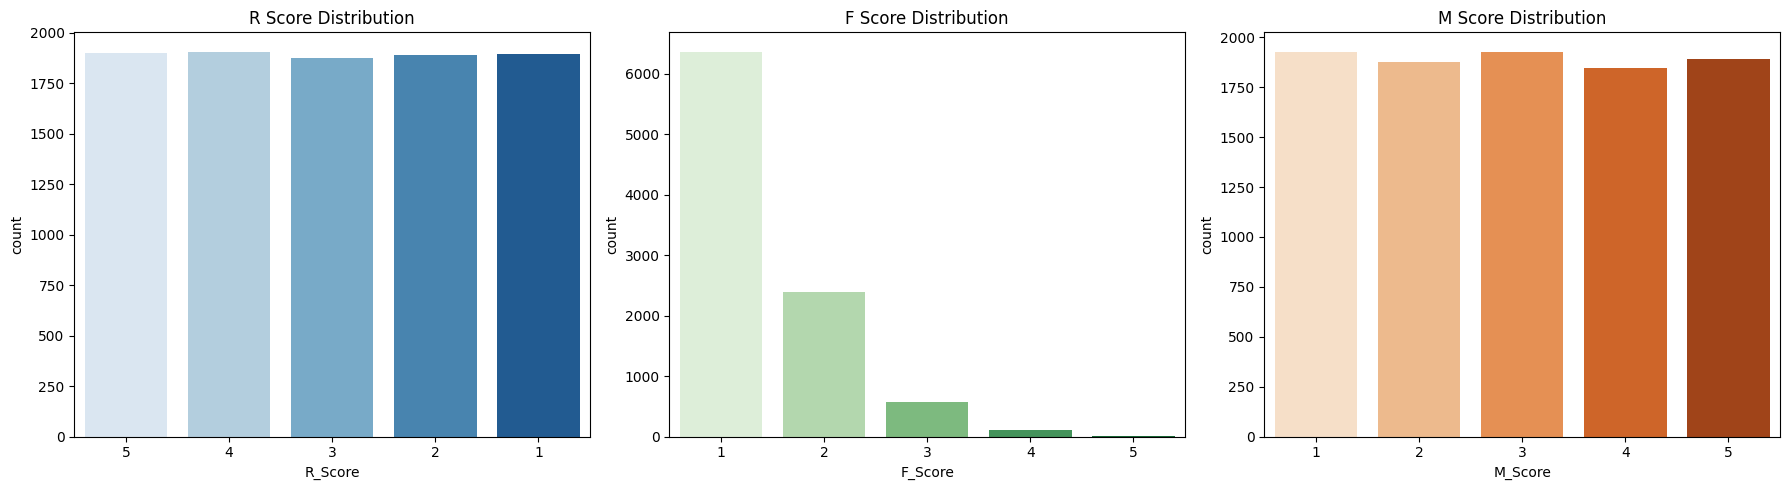

In [20]:
# ==================== 3. 计算RFM指标（按客户聚合） ====================
print("\n" + "="*70)
print("【Step 1：计算RFM基础指标】")
print("="*70)

# 确定分析截止日期（数据最后一天）
analysis_date = df['Purchase Date'].max()
print(f"✓ 分析截止日期：{analysis_date.strftime('%Y-%m-%d')}")

# 按Customer ID聚合计算RFM
rfm_raw = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (analysis_date - x.max()).days,  # R值：最近一次购买距今天数
    'Order Status': 'count',  # F值：购买次数（用Order Status计数）
    'Total Price': 'sum'  # M值：总消费金额
}).rename(columns={
    'Purchase Date': 'R_Recency',
    'Order Status': 'F_Frequency',
    'Total Price': 'M_Monetary'
}).reset_index()

print(f"✓ RFM基础数据计算完成，共 {len(rfm_raw):,} 个客户")

# 查看RFM基础统计
print("\n【RFM原始值统计描述】")
print(rfm_raw[['R_Recency', 'F_Frequency', 'M_Monetary']].describe().round(2).to_string())

# ==================== 4. RFM评分量化 ====================
print("\n" + "="*70)
print("【Step 2：RFM评分量化（1-5 Scores）】")
print("="*70)

# 4.1 R值评分（Recency - 越小越好）
# R值越小（最近购买），分数越高
r_labels = [5, 4, 3, 2, 1]  # 最近的分5分，最久的分1分
rfm_raw['R_Score'] = pd.qcut(rfm_raw['R_Recency'], q=5, labels=r_labels, duplicates='drop')

print("\n【R值评分分布】")
print(f"R值范围：{rfm_raw['R_Recency'].min():.0f} - {rfm_raw['R_Recency'].max():.0f} 天")
print(rfm_raw['R_Score'].value_counts().sort_index().to_string())

# 4.2 M值评分（Monetary - 越大越好）
# 消费金额越高，分数越高
m_labels = [1, 2, 3, 4, 5]  # 消费最少的1分，最多的5分
rfm_raw['M_Score'] = pd.qcut(rfm_raw['M_Monetary'], q=5, labels=m_labels, duplicates='drop')

print("\n【M值评分分布】")
print(f"M值范围：{rfm_raw['M_Monetary'].min():.2f} - {rfm_raw['M_Monetary'].max():.2f}")
print(rfm_raw['M_Score'].value_counts().sort_index().to_string())

# 4.3 F值评分（Frequency - 使用数值1-5直接划分）
# 注意：F值已经是购买次数，但可能分布不均匀，直接按次数划分
def score_frequency(freq):
    """根据购买次数直接评分"""
    if freq >= 5:
        return 5
    elif freq == 4:
        return 4
    elif freq == 3:
        return 3
    elif freq == 2:
        return 2
    else:
        return 1

rfm_raw['F_Score'] = rfm_raw['F_Frequency'].apply(score_frequency)

print("\n【F值评分分布】")
print(f"F值范围：{rfm_raw['F_Frequency'].min():.0f} - {rfm_raw['F_Frequency'].max():.0f} 次")
print(rfm_raw['F_Score'].value_counts().sort_index().to_string())

# 显示评分后统计
print("\n【RFM评分统计】")
print(rfm_raw[['R_Score', 'F_Score', 'M_Score']].describe().to_string())

# RFM的分布图
print("\n【RFM评分分布】")
import matplotlib.pyplot as plt
import seaborn as sns   
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.countplot(x='R_Score', data=rfm_raw, palette='Blues')
plt.title('R Score Distribution')
plt.subplot(1, 3, 2)
sns.countplot(x='F_Score', data=rfm_raw, palette='Greens')
plt.title('F Score Distribution')
plt.subplot(1, 3, 3)
sns.countplot(x='M_Score', data=rfm_raw, palette='Oranges')
plt.title('M Score Distribution')
plt.tight_layout()
plt.show()


In [21]:
# ==================== 5. 客户分群 ====================
print("\n" + "="*70)
print("【Step 3：客户分群（八类客户划分）】")
print("="*70)

# 5.1 定义分群函数
def rfm_segment(row):
    """
    基于RFM评分进行八类客户划分
    规则：
    - 高价值客户：R高(4-5) + F高(4-5) + M高(4-5)
    - 重要发展客户：R高(4-5) + F低(1-3) + M高(4-5)
    - 重要保持客户：R低(1-3) + F高(4-5) + M高(4-5)
    - 重要挽留客户：R低(1-3) + F低(1-3) + M高(4-5)
    - 一般价值客户：R高(4-5) + F高(4-5) + M低(1-3)
    - 一般发展客户：R高(4-5) + F低(1-3) + M低(1-3)
    - 一般保持客户：R低(1-3) + F高(4-5) + M低(1-3)
    - 一般挽留客户：R低(1-3) + F低(1-3) + M低(1-3)
    """
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    
    # 高价值客户
    if r >= 4 and f >= 4 and m >= 4:
        return '⭐ 重要价值客户'
    # 重要发展客户
    elif r >= 4 and f <= 3 and m >= 4:
        return '📈 重要发展客户'
    # 重要保持客户
    elif r <= 3 and f >= 4 and m >= 4:
        return '⚓ 重要保持客户'
    # 重要挽留客户
    elif r <= 3 and f <= 3 and m >= 4:
        return '🆘 重要挽留客户'
    # 一般价值客户
    elif r >= 4 and f >= 4 and m <= 3:
        return '💎 一般价值客户'
    # 一般发展客户
    elif r >= 4 and f <= 3 and m <= 3:
        return '🌱 一般发展客户'
    # 一般保持客户
    elif r <= 3 and f >= 4 and m <= 3:
        return '🔄 一般保持客户'
    # 一般挽留客户
    else:
        return '📉 一般挽留客户'

# 5.2 应用分群函数
rfm_raw['Segment'] = rfm_raw.apply(rfm_segment, axis=1)

# 5.3 统计各客户群数量
segment_counts = rfm_raw['Segment'].value_counts().reset_index()
segment_counts.columns = ['客户类型', '客户数量']
segment_counts['占比%'] = (segment_counts['客户数量'] / len(rfm_raw) * 100).round(2)

print("\n【八类客户分布】")
print(segment_counts.to_string(index=False))

# ==================== 5.4 计算各客户群的价值贡献 ====================
segment_value = rfm_raw.groupby('Segment').agg({
    'M_Monetary': ['sum', 'mean', 'count'],
    'F_Frequency': 'mean',
    'R_Recency': 'mean'
}).round(2)

# 重命名列 - 注意这里需要正确处理多层索引
segment_value.columns = ['总消费金额', '平均消费金额', '客户数', '平均购买次数', '平均最近购买天数']
segment_value = segment_value.reset_index()

# 计算消费占比
total_revenue = segment_value['总消费金额'].sum()
segment_value['消费占比%'] = (segment_value['总消费金额'] / total_revenue * 100).round(2)

# 确认列名
print("\n【segment_value列名检查】")
print(segment_value.columns.tolist())
print("\n【各客户群价值贡献分析】")
print(segment_value)

# ==================== 6. 识别高价值客户 ====================
print("\n" + "="*70)
print("【Step 4：高价值客户识别】")
print("="*70)

# 6.1 定义高价值客户（重要价值客户 + 重要发展客户）
high_value_customers = rfm_raw[rfm_raw['Segment'].isin(['⭐ 重要价值客户', '📈 重要发展客户'])]

print(f"\n✓ 高价值客户总数：{len(high_value_customers):,} 个")
print(f"✓ 占客户总数比例：{len(high_value_customers)/len(rfm_raw)*100:.2f}%")

# 6.2 高价值客户贡献分析
high_value_stats = {
    '客户数': len(high_value_customers),
    '总消费金额': f"{high_value_customers['M_Monetary'].sum():,.2f}",
    '消费占比': f"{high_value_customers['M_Monetary'].sum()/total_revenue*100:.2f}%",
    '平均消费金额': f"{high_value_customers['M_Monetary'].mean():,.2f}",
    '平均购买次数': f"{high_value_customers['F_Frequency'].mean():.2f}",
    '平均最近购买天数': f"{high_value_customers['R_Recency'].mean():.1f} 天"
}

print("\n【高价值客户贡献分析】")
for key, value in high_value_stats.items():
    print(f"  {key}: {value}")

# 6.3 导出高价值客户名单
print("\n【高价值客户名单（前20名）】")
top_customers = high_value_customers.nlargest(20, 'M_Monetary')[['Customer ID', 'R_Recency', 'F_Frequency', 'M_Monetary', 'Segment']]
print(top_customers.to_string(index=False))


【Step 3：客户分群（八类客户划分）】

【八类客户分布】
    客户类型  客户数量   占比%
📉 一般挽留客户  3744 39.55
🌱 一般发展客户  1974 20.85
🆘 重要挽留客户  1888 19.95
📈 重要发展客户  1725 18.22
⭐ 重要价值客户   102  1.08
⚓ 重要保持客户    25  0.26
💎 一般价值客户     6  0.06
🔄 一般保持客户     2  0.02

【segment_value列名检查】
['Segment', '总消费金额', '平均消费金额', '客户数', '平均购买次数', '平均最近购买天数', '消费占比%']

【各客户群价值贡献分析】
    Segment        总消费金额    平均消费金额   客户数  平均购买次数  平均最近购买天数  消费占比%
0  ⚓ 重要保持客户    343384.15  13735.37    25    4.16    145.60   0.81
1  ⭐ 重要价值客户   1507845.27  14782.80   102    4.19     36.74   3.54
2  🆘 重要挽留客户  14329064.66   7589.55  1888    1.51    187.03  33.61
3  🌱 一般发展客户   4368375.35   2212.96  1974    1.28     49.08  10.25
4  💎 一般价值客户     14385.46   2397.58     6    4.00     39.67   0.03
5  📈 重要发展客户  14749068.42   8550.18  1725    1.90     46.94  34.60
6  📉 一般挽留客户   7313162.18   1953.30  3744    1.13    207.70  17.16
7  🔄 一般保持客户      4330.08   2165.04     2    4.00    130.50   0.01

【Step 4：高价值客户识别】

✓ 高价值客户总数：1,827 个
✓ 占客户总数比例：19.30%

【高价值客户贡献分析】
  客户数: 1827
 


【步骤5：RFM可视化分析】

【评分转换检查】
R_Score 类型: category -> int64
F_Score 类型: int64 -> int64
M_Score 类型: category -> int64

【热力图数据预览】
F_Score_num         1         2         3         4    5
R_Score_num                                             
1            2.369139  3.507772  3.785714  5.000000  0.0
2            2.529938  3.688482  4.360000  5.000000  5.0
3            2.568852  3.806391  4.427184  4.526316  5.0
4            2.583255  3.913600  4.459893  4.680000  5.0
5            2.627513  3.842424  4.470320  4.791045  5.0


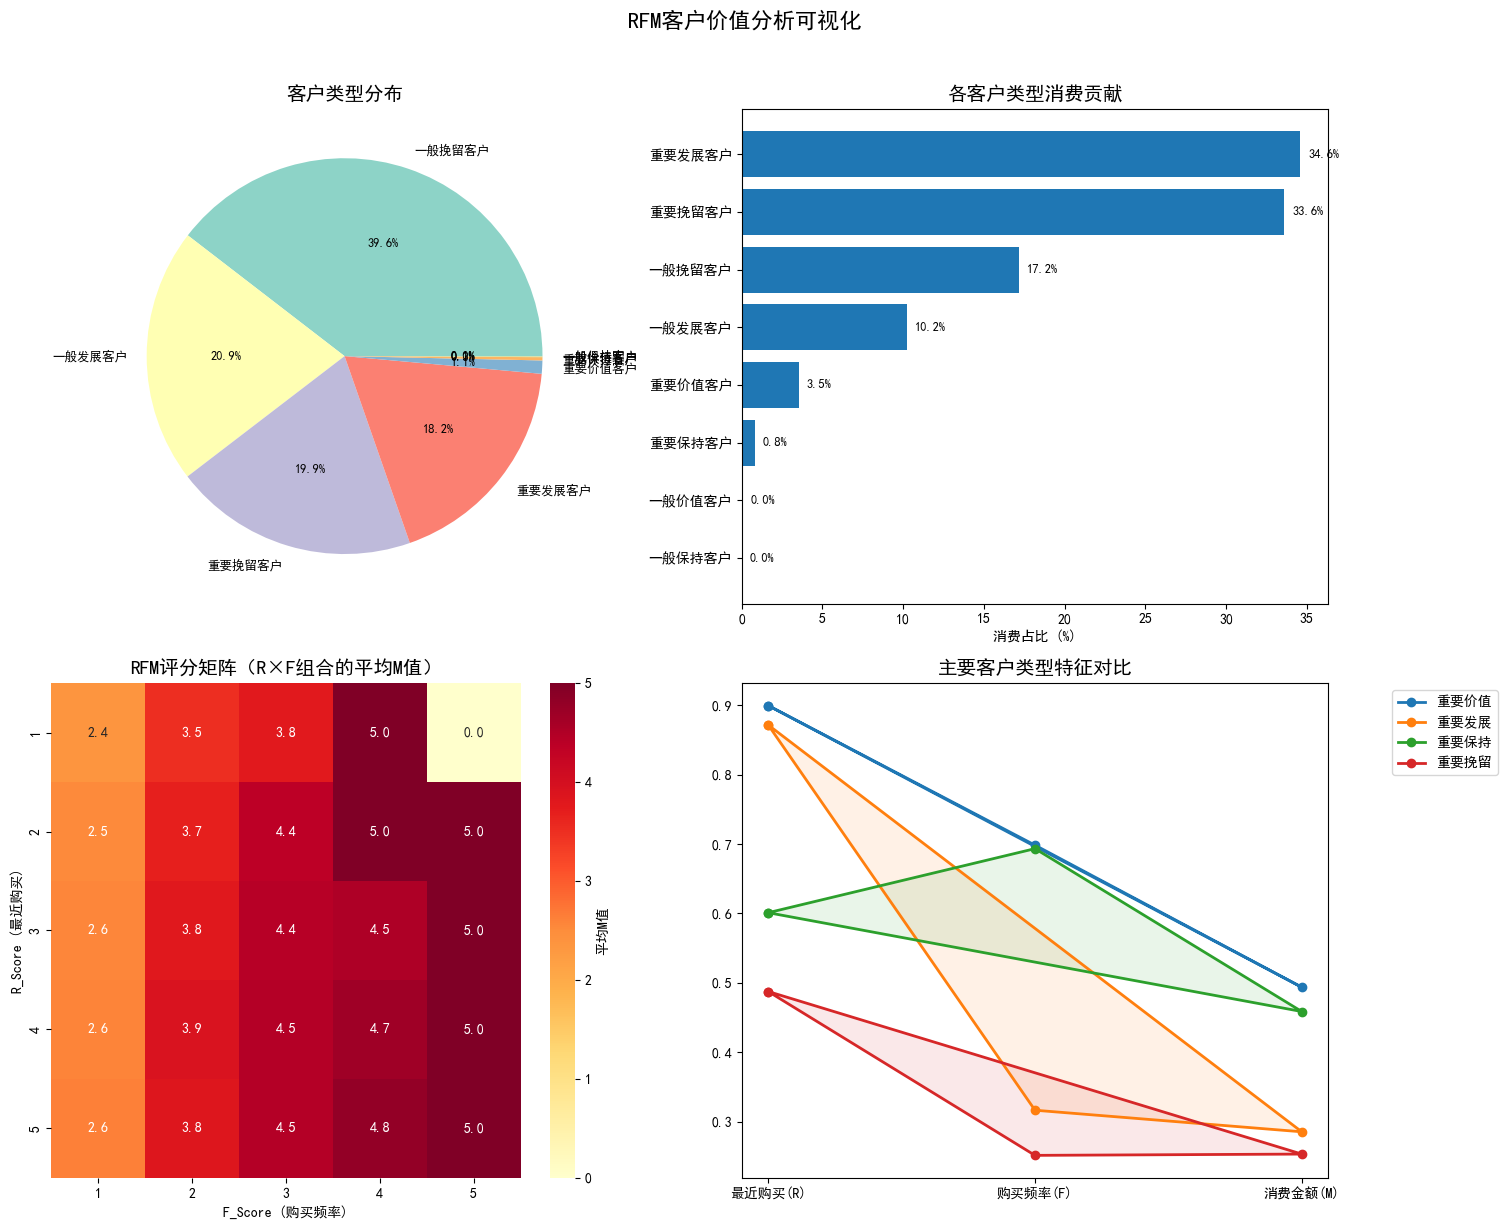

✓ 可视化图表已生成并保存为 'rfm_analysis.png'


In [22]:
# ==================== 7. 可视化分析 ====================
print("\n" + "="*70)
print("【步骤5：RFM可视化分析】")
print("="*70)

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 设置中文字体
    plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
    plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
    
    # 创建图形
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # ========== 7.1 客户类型分布饼图 ==========
    ax1 = axes[0, 0]
    
    # 使用segment_counts（这是之前正确创建的）
    segment_counts_sorted = segment_counts.sort_values('客户数量', ascending=False)
    
    # 确保标签长度适中，避免重叠
    labels = [label.replace('⭐ ', '').replace('📈 ', '').replace('⚓ ', '').replace('🆘 ', '')
              .replace('💎 ', '').replace('🌱 ', '').replace('🔄 ', '').replace('📉 ', '')
              for label in segment_counts_sorted['客户类型']]
    
    colors = plt.cm.Set3(range(len(segment_counts_sorted)))
    wedges, texts, autotexts = ax1.pie(segment_counts_sorted['客户数量'], 
                                        labels=labels,
                                        autopct='%1.1f%%',
                                        colors=colors,
                                        textprops={'fontsize': 9})
    ax1.set_title('客户类型分布', fontsize=14, fontweight='bold')
    
    # ========== 7.2 消费金额分布条形图 ==========
    ax2 = axes[0, 1]
    
    # 使用正确的列名 - 这里用'Segment'而不是'客户类型'
    segment_value_sorted = segment_value.sort_values('消费占比%', ascending=True)
    
    # 简化标签显示
    simple_labels = [label.replace('⭐ ', '').replace('📈 ', '').replace('⚓ ', '').replace('🆘 ', '')
                     .replace('💎 ', '').replace('🌱 ', '').replace('🔄 ', '').replace('📉 ', '')
                     for label in segment_value_sorted['Segment']]
    
    bars = ax2.barh(simple_labels, segment_value_sorted['消费占比%'])
    ax2.set_xlabel('消费占比 (%)')
    ax2.set_title('各客户类型消费贡献', fontsize=14, fontweight='bold')
    
    # 为条形添加数值标签
    for i, (bar, val) in enumerate(zip(bars, segment_value_sorted['消费占比%'])):
        ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
                 va='center', fontsize=9)
    
    # ========== 7.3 RFM评分热力图（修正版） ==========
    ax3 = axes[1, 0]
    
    # 关键修正：将所有评分转换为数值类型
    # 创建数值型评分的副本
    rfm_heatmap = rfm_raw.copy()
    
    # 将R_Score, F_Score, M_Score转换为整数
    # 注意：这些列可能是category类型或object类型，需要先转换为数值
    rfm_heatmap['R_Score_num'] = pd.to_numeric(rfm_heatmap['R_Score'], errors='coerce')
    rfm_heatmap['F_Score_num'] = pd.to_numeric(rfm_heatmap['F_Score'], errors='coerce')
    rfm_heatmap['M_Score_num'] = pd.to_numeric(rfm_heatmap['M_Score'], errors='coerce')
    
    # 检查转换后的数据
    print("\n【评分转换检查】")
    print(f"R_Score 类型: {rfm_heatmap['R_Score'].dtype} -> {rfm_heatmap['R_Score_num'].dtype}")
    print(f"F_Score 类型: {rfm_heatmap['F_Score'].dtype} -> {rfm_heatmap['F_Score_num'].dtype}")
    print(f"M_Score 类型: {rfm_heatmap['M_Score'].dtype} -> {rfm_heatmap['M_Score_num'].dtype}")
    
    # 计算每个R_Score和F_Score组合的平均M_Score
    # 使用数值型列进行计算
    rfm_pivot = rfm_heatmap.pivot_table(
        values='M_Score_num',  # 使用转换后的数值列
        index='R_Score_num', 
        columns='F_Score_num', 
        aggfunc='mean',
        fill_value=0  # 填充空值为0
    )
    
    # 确保索引和列按顺序排列
    rfm_pivot = rfm_pivot.sort_index().sort_index(axis=1)
    
    print("\n【热力图数据预览】")
    print(rfm_pivot)
    
    # 绘制热力图
    sns.heatmap(rfm_pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax3,
                cbar_kws={'label': '平均M值'})
    ax3.set_title('RFM评分矩阵（R×F组合的平均M值）', fontsize=14, fontweight='bold')
    ax3.set_xlabel('F_Score (购买频率)')
    ax3.set_ylabel('R_Score (最近购买)')
    
    # ========== 7.4 高价值客户特征雷达图 ==========
    ax4 = axes[1, 1]
    
    # 准备雷达图数据
    segments_for_radar = ['⭐ 重要价值客户', '📈 重要发展客户', '⚓ 重要保持客户', '🆘 重要挽留客户']
    radar_data = []
    
    for segment in segments_for_radar:
        if segment in segment_value['Segment'].values:
            row = segment_value[segment_value['Segment'] == segment].iloc[0]
            # 归一化处理用于雷达图
            radar_data.append({
                'Segment': segment,
                'R_Score_norm': 1 - (row['平均最近购买天数'] / rfm_raw['R_Recency'].max()),  # R值越小越好
                'F_Score_norm': row['平均购买次数'] / rfm_raw['F_Frequency'].max(),
                'M_Score_norm': row['平均消费金额'] / rfm_raw['M_Monetary'].max()
            })
    
    if radar_data:
        radar_df = pd.DataFrame(radar_data)
        
        # 设置雷达图角度
        categories = ['最近购买(R)', '购买频率(F)', '消费金额(M)']
        N = len(categories)
        angles = [n / float(N) * 2 * 3.14159 for n in range(N)]
        angles += angles[:1]
        
        # 绘制雷达图
        for idx, row in radar_df.iterrows():
            values = row[['R_Score_norm', 'F_Score_norm', 'M_Score_norm']].values.tolist()
            values += values[:1]
            
            # 简化图例标签
            simple_legend = row['Segment'].replace('⭐ ', '').replace('📈 ', '').replace('⚓ ', '').replace('🆘 ', '')[:4]
            
            ax4.plot(angles, values, 'o-', linewidth=2, label=simple_legend)
            ax4.fill(angles, values, alpha=0.1)
        
        ax4.set_xticks(angles[:-1])
        ax4.set_xticklabels(categories)
        ax4.set_title('主要客户类型特征对比', fontsize=14, fontweight='bold')
        ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    else:
        ax4.text(0.5, 0.5, '无足够数据生成雷达图', ha='center', va='center', transform=ax4.transAxes)
    
    plt.suptitle('RFM客户价值分析可视化', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('rfm_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ 可视化图表已生成并保存为 'rfm_analysis.png'")
    
except ImportError as e:
    print(f"⚠️ 可视化库未安装，跳过图表生成：{e}")
    print("如需生成图表，请安装：pip install matplotlib seaborn")
except Exception as e:
    print(f"⚠️ 生成可视化图表时出错：{e}")
    import traceback
    traceback.print_exc()

In [23]:
# ==================== 10. K-means聚类分析 ====================
print("\n" + "="*70)
print("【K-means聚类分析】")
print("="*70)

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 10.1 准备聚类数据
print("\n【步骤1：准备聚类数据】")

# 选择RFM原始值作为聚类变量
cluster_data = rfm_raw[['R_Recency', 'F_Frequency', 'M_Monetary']].copy()

# 检查并处理异常值（可选）
# 这里保留原始值，因为聚类时会进行标准化

print(f"✓ 聚类数据形状：{cluster_data.shape}")
print("\n【聚类变量统计描述】")
print(cluster_data.describe().round(2).to_string())

# 10.2 数据标准化
print("\n【步骤2：数据标准化】")

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

# 将标准化后的数据转换回DataFrame便于查看
cluster_scaled_df = pd.DataFrame(cluster_scaled, 
                                  columns=['R_Recency_scaled', 'F_Frequency_scaled', 'M_Monetary_scaled'])

print("✓ 数据已完成标准化（均值为0，标准差为1）")
print("\n【标准化后数据统计描述】")
print(cluster_scaled_df.describe().round(2).to_string())




【K-means聚类分析】

【步骤1：准备聚类数据】
✓ 聚类数据形状：(9466, 3)

【聚类变量统计描述】
       R_Recency  F_Frequency  M_Monetary
count    9466.00      9466.00     9466.00
mean      139.07         1.42     4503.45
std        93.89         0.68     3845.51
min         0.00         1.00       20.75
25%        59.00         1.00     1582.38
50%       127.00         1.00     3610.26
75%       209.00         2.00     6650.00
max       365.00         6.00    29937.93

【步骤2：数据标准化】
✓ 数据已完成标准化（均值为0，标准差为1）

【标准化后数据统计描述】
       R_Recency_scaled  F_Frequency_scaled  M_Monetary_scaled
count           9466.00             9466.00            9466.00
mean              -0.00               -0.00              -0.00
std                1.00                1.00               1.00
min               -1.48               -0.61              -1.17
25%               -0.85               -0.61              -0.76
50%               -0.13               -0.61              -0.23
75%                0.74                0.85               0.56
max     

In [24]:
# 10.3 绘制肘部图确定最佳K值
print("\n" + "="*70)
print("【步骤3：肘部图分析 - 确定最佳K值】")
print("="*70)

# 计算不同K值的SSE（误差平方和）
sse = []
silhouette_scores = []
K_range = range(2, 11)  # 测试K从2到10

from sklearn.metrics import silhouette_score

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    sse.append(kmeans.inertia_)
        # 计算轮廓系数（需要至少2个簇）
    if k >= 2:
        labels = kmeans.labels_
        silhouette_scores.append(silhouette_score(cluster_scaled, labels))

print("✓ 完成K值计算（2-10）")


【步骤3：肘部图分析 - 确定最佳K值】
✓ 完成K值计算（2-10）


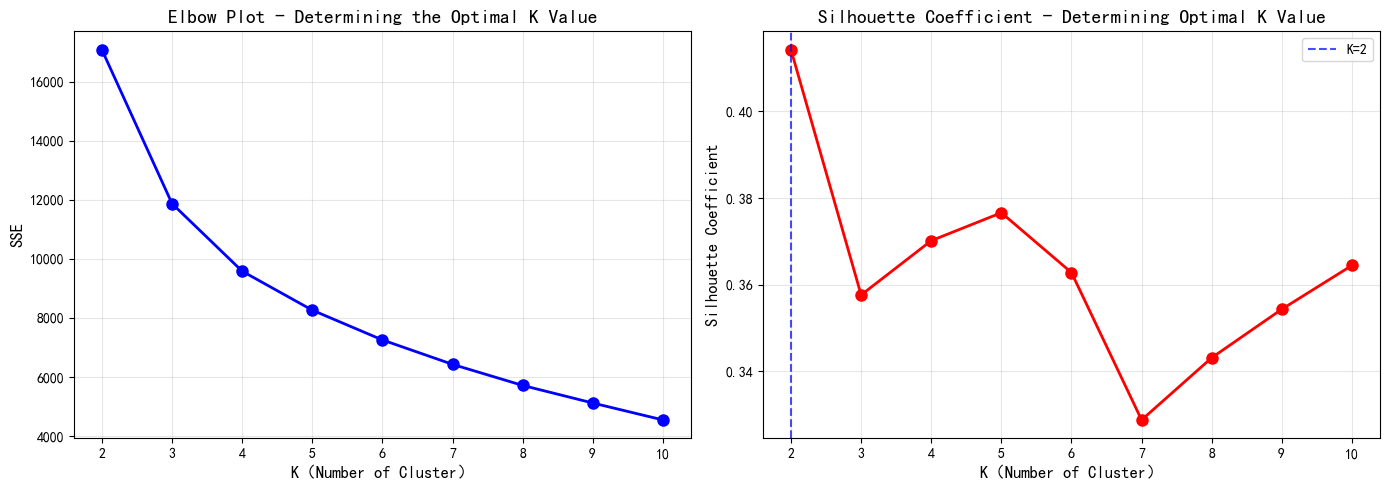

✓ 肘部图已保存为 'kmeans_elbow.png'

【最佳K值建议】
  肘部图法建议K值：未明显识别
  轮廓系数法建议K值：2 (轮廓系数: 0.414)


In [30]:
# 绘制肘部图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：肘部图（SSE）
ax1 = axes[0]
ax1.plot(list(K_range), sse, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('K（Number of Cluster）', fontsize=12)
ax1.set_ylabel('SSE', fontsize=12)
ax1.set_title('Elbow Plot - Determining the Optimal K Value', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 添加肘部标注（找到下降趋缓的点）
# 计算下降率
sse_diff = [sse[i] - sse[i+1] for i in range(len(sse)-1)]
sse_diff_ratio = [sse_diff[i] / sse[i] for i in range(len(sse_diff))]

# 找到下降率变化最大的点（肘部）
optimal_k_elbow = None
for i in range(1, len(sse_diff_ratio)):
    if sse_diff_ratio[i] < sse_diff_ratio[i-1] * 0.5:  # 下降率减半
        optimal_k_elbow = i + 2  # +2因为K从2开始
        break

if optimal_k_elbow:
    ax1.axvline(x=optimal_k_elbow, color='r', linestyle='--', alpha=0.7, 
                label=f'Optional K={optimal_k_elbow}')
    ax1.legend()
# 右图：轮廓系数
ax2 = axes[1]
ax2.plot(list(K_range), silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('K（Number of Cluster）', fontsize=12)
ax2.set_ylabel('Silhouette Coefficient', fontsize=12)
ax2.set_title('Silhouette Coefficient - Determining Optimal K Value', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 找到轮廓系数最大的K值
optimal_k_silhouette = K_range[silhouette_scores.index(max(silhouette_scores))]
ax2.axvline(x=optimal_k_silhouette, color='b', linestyle='--', alpha=0.7, 
            label=f'K={optimal_k_silhouette}')
ax2.legend()

plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ 肘部图已保存为 'kmeans_elbow.png'")

print(f"\n【最佳K值建议】")
print(f"  肘部图法建议K值：{optimal_k_elbow if optimal_k_elbow else '未明显识别'}")
print(f"  轮廓系数法建议K值：{optimal_k_silhouette} (轮廓系数: {max(silhouette_scores):.3f})")


In [26]:
# 10.4 选择K值并执行聚类
print("\n" + "="*70)
print("【Step 4：执行K-means聚类】")
print("="*70)

# 根据肘部图结果选择K值
# 这里可以选择肘部图建议的值，或者轮廓系数建议的值
# 通常取轮廓系数最大的K值
selected_k = 5

print(f"✓ 选择K值：{selected_k}")

# 执行最终聚类
final_kmeans = KMeans(n_clusters=selected_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(cluster_scaled)
# 将聚类标签添加到原始数据
rfm_raw['Cluster'] = cluster_labels

print(f"✓ 完成聚类，共 {selected_k} 个簇")

# 10.5 查看聚类中心
print("\n" + "="*70)
print("【Step 5：聚类中心分析】")
print("="*70)

# 获取聚类中心（标准化后的值）
centers_scaled = final_kmeans.cluster_centers_

# 将聚类中心转换回原始尺度
centers_original = scaler.inverse_transform(centers_scaled)
# 创建聚类中心DataFrame
centers_df = pd.DataFrame(centers_original, 
                          columns=['R_Recency', 'F_Frequency', 'M_Monetary'])
centers_df.index.name = 'Cluster'
centers_df = centers_df.reset_index()

print("\n【各簇聚类中心（原始值）】")
print(centers_df.round(2).to_string(index=False))

# 添加聚类中心（标准化值）便于比较
centers_scaled_df = pd.DataFrame(centers_scaled, 
                                  columns=['R_scaled', 'F_scaled', 'M_scaled'])
centers_scaled_df.index.name = 'Cluster'
centers_scaled_df = centers_scaled_df.reset_index()

print("\n【各簇聚类中心（标准化值）】")
print(centers_scaled_df.round(2).to_string(index=False))

# 10.6 统计各簇客户数量
print("\n" + "="*70)
print("【步骤6：各簇客户数量统计】")
print("="*70)

cluster_counts = rfm_raw['Cluster'].value_counts().sort_index().reset_index()
cluster_counts.columns = ['Cluster', '客户数量']
cluster_counts['占比%'] = (cluster_counts['客户数量'] / len(rfm_raw) * 100).round(2)

print("\n【各簇客户分布】")
print(cluster_counts.to_string(index=False))


【Step 4：执行K-means聚类】
✓ 选择K值：5
✓ 完成聚类，共 5 个簇

【Step 5：聚类中心分析】

【各簇聚类中心（原始值）】
 Cluster  R_Recency  F_Frequency  M_Monetary
       0      84.13         2.14     4115.32
       1     248.17         1.05     2842.70
       2      67.94         3.30    12580.86
       3      83.16         1.00     2915.00
       4     107.91         1.80    10130.78

【各簇聚类中心（标准化值）】
 Cluster  R_scaled  F_scaled  M_scaled
       0     -0.59      1.05     -0.10
       1      1.16     -0.54     -0.43
       2     -0.76      2.75      2.10
       3     -0.60     -0.61     -0.41
       4     -0.33      0.56      1.46

【步骤6：各簇客户数量统计】

【各簇客户分布】
 Cluster  客户数量   占比%
       0  1475 15.58
       1  3067 32.40
       2   513  5.42
       3  3226 34.08
       4  1185 12.52



【步骤7：各簇RFM特征分析】

【各簇RFM特征详细分析】
 Cluster   R_平均  R_中位数  R_最小值  R_最大值  F_平均  F_中位数  F_最小值  F_最大值     M_平均    M_中位数   M_最小值    M_最大值  客户数量
       0  84.13   74.0      0    321  2.14    2.0      2      4  4115.32  4279.39   83.00  7769.65  1475
       1 248.18  241.0    166    365  1.05    1.0      1      2  2838.24  2359.23   20.75 10257.12  3067
       2  67.94   54.0      0    355  3.30    3.0      2      6 12580.86 11598.97 3068.10 29937.93   513
       3  83.13   83.0      0    166  1.00    1.0      1      1  2913.55  2470.30   20.75  7977.76  3226
       4 108.17  102.0      0    338  1.80    2.0      1      3 10127.90  9632.64 6377.77 21653.92  1185

【步骤8：簇特征可视化】


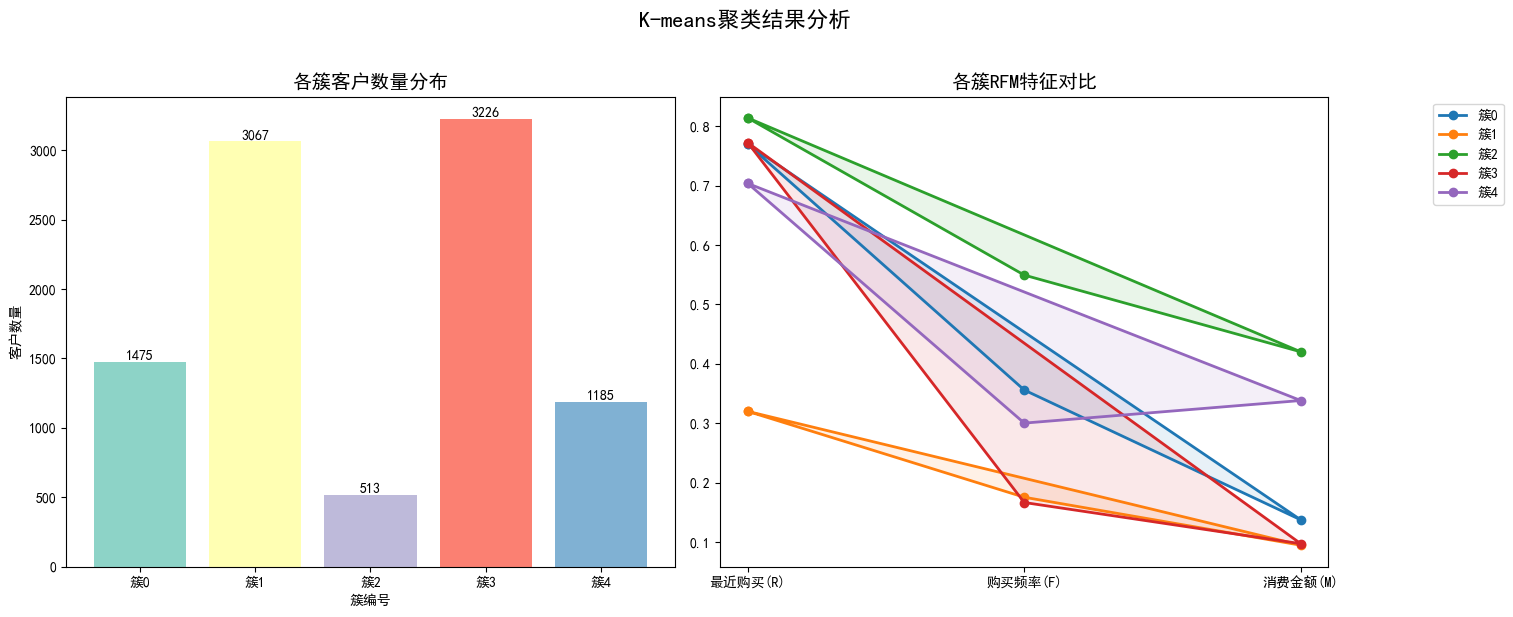

✓ 聚类结果图已保存为 'kmeans_clusters.png'


In [27]:

# 10.7 各簇的RFM特征分析
print("\n" + "="*70)
print("【步骤7：各簇RFM特征分析】")
print("="*70)

# 按簇分组计算RFM统计量
cluster_profile = rfm_raw.groupby('Cluster').agg({
    'R_Recency': ['mean', 'median', 'min', 'max'],
    'F_Frequency': ['mean', 'median', 'min', 'max'],
    'M_Monetary': ['mean', 'median', 'min', 'max'],
    'Customer ID': 'count'
}).round(2)

# 重命名列
cluster_profile.columns = ['R_平均', 'R_中位数', 'R_最小值', 'R_最大值',
                            'F_平均', 'F_中位数', 'F_最小值', 'F_最大值',
                            'M_平均', 'M_中位数', 'M_最小值', 'M_最大值',
                            '客户数量']
cluster_profile = cluster_profile.reset_index()

print("\n【各簇RFM特征详细分析】")
print(cluster_profile.to_string(index=False))

# 10.8 簇特征雷达图
print("\n" + "="*70)
print("【步骤8：簇特征可视化】")
print("="*70)

# 准备雷达图数据
# 对RFM值进行归一化
r_max = rfm_raw['R_Recency'].max()
f_max = rfm_raw['F_Frequency'].max()
m_max = rfm_raw['M_Monetary'].max()

# 为每个簇计算归一化值（用于雷达图）
radar_data = []
for cluster in range(selected_k):
    cluster_data = rfm_raw[rfm_raw['Cluster'] == cluster]
    
    # R值需要反向（越小越好，所以用1-归一化值）
    r_norm = 1 - (cluster_data['R_Recency'].mean() / r_max)
    f_norm = cluster_data['F_Frequency'].mean() / f_max
    m_norm = cluster_data['M_Monetary'].mean() / m_max
    
    radar_data.append({
        'Cluster': f'簇{cluster}',
        'R_norm': r_norm,
        'F_norm': f_norm,
        'M_norm': m_norm
    })

radar_df = pd.DataFrame(radar_data)

# 绘制雷达图
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 左图：簇规模分布
ax1 = axes[0]
colors = plt.cm.Set3(range(selected_k))
bars = ax1.bar(range(selected_k), cluster_counts['客户数量'], color=colors)
ax1.set_xlabel('簇编号')
ax1.set_ylabel('客户数量')
ax1.set_title('各簇客户数量分布', fontsize=14, fontweight='bold')
ax1.set_xticks(range(selected_k))
ax1.set_xticklabels([f'簇{i}' for i in range(selected_k)])

# 在柱状图上添加数值标签
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{int(height)}', ha='center', va='bottom')

# 右图：簇特征雷达图
ax2 = axes[1]

# 设置雷达图角度
categories = ['最近购买(R)', '购买频率(F)', '消费金额(M)']
N = len(categories)
angles = [n / float(N) * 2 * 3.14159 for n in range(N)]
angles += angles[:1]

# 绘制每个簇的雷达图
for idx, row in radar_df.iterrows():
    values = row[['R_norm', 'F_norm', 'M_norm']].values.tolist()
    values += values[:1]
    
    ax2.plot(angles, values, 'o-', linewidth=2, label=f'簇{idx}')
    ax2.fill(angles, values, alpha=0.1)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories)
ax2.set_title('各簇RFM特征对比', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.suptitle('K-means聚类结果分析', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ 聚类结果图已保存为 'kmeans_clusters.png'")

In [28]:
# 10.9 簇特征解读
print("\n" + "="*70)
print("【步骤9：簇特征解读】")
print("="*70)

print("\n【各簇特征描述】")
for cluster in range(selected_k):
    cluster_data = rfm_raw[rfm_raw['Cluster'] == cluster]
    
    r_mean = cluster_data['R_Recency'].mean()
    f_mean = cluster_data['F_Frequency'].mean()
    m_mean = cluster_data['M_Monetary'].mean()
    
    # 与整体平均水平比较
    r_avg = rfm_raw['R_Recency'].mean()
    f_avg = rfm_raw['F_Frequency'].mean()
    m_avg = rfm_raw['M_Monetary'].mean()
    
    # 判断特征
    r_char = "较近" if r_mean < r_avg else "较远"
    f_char = "高频" if f_mean > f_avg else "低频"
    m_char = "高消费" if m_mean > m_avg else "低消费"
    
    print(f"\n【簇{cluster}】({cluster_counts[cluster_counts['Cluster']==cluster]['客户数量'].values[0]} 客户, {cluster_counts[cluster_counts['Cluster']==cluster]['占比%'].values[0]}%)")
    print(f"  特征：{r_char}购买、{f_char}、{m_char}")
    print(f"  R(最近购买): {r_mean:.1f}天 (平均 {r_avg:.1f}天)")
    print(f"  F(购买次数): {f_mean:.2f}次 (平均 {f_avg:.2f}次)")
    print(f"  M(消费金额): {m_mean:.2f} (平均 {m_avg:.2f})")

    # 10.10 聚类结果与RFM分群对比
print("\n" + "="*70)
print("【步骤10：聚类结果与RFM分群对比】")
print("="*70)

# 创建交叉表
if 'Segment' in rfm_raw.columns:
    cross_tab = pd.crosstab(
        rfm_raw['Cluster'], 
        rfm_raw['Segment'],
        margins=True,
        margins_name='总计'
    )
    
    print("\n【聚类簇 vs RFM分群 交叉分析】")
    print(cross_tab.to_string())
    
    # 计算每个簇中主要的RFM分群
    print("\n【各簇主要客户类型】")
    for cluster in range(selected_k):
        cluster_segments = rfm_raw[rfm_raw['Cluster'] == cluster]['Segment'].value_counts()
        top_segment = cluster_segments.index[0]
        top_pct = (cluster_segments.iloc[0] / cluster_segments.sum() * 100).round(2)
        print(f"  簇{cluster}: 主要类型「{top_segment}」({top_pct}%)")

# 10.11 导出聚类结果
print("\n" + "="*70)
print("【步骤11：导出聚类结果】")
print("="*70)

output_file = 'rfm_kmeans_results.xlsx'
try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        # Sheet1: 带有聚类标签的RFM数据
        rfm_raw.to_excel(writer, sheet_name='RFM聚类结果', index=False)
        
        # Sheet2: 聚类中心
        centers_df.to_excel(writer, sheet_name='聚类中心', index=False)
        
        # Sheet3: 簇规模统计
        cluster_counts.to_excel(writer, sheet_name='簇规模统计', index=False)
        
        # Sheet4: 簇特征分析
        cluster_profile.to_excel(writer, sheet_name='簇特征分析', index=False)
        
        # Sheet5: 雷达图数据
        radar_df.to_excel(writer, sheet_name='雷达图数据', index=False)
    
    print(f"✓ 聚类结果已导出到：{output_file}")
    print(f"  - Sheet1: RFM聚类结果 ({len(rfm_raw)} 条)")
    print(f"  - Sheet2: 聚类中心 ({selected_k} 个簇)")
    print(f"  - Sheet3: 簇规模统计 ({selected_k} 个簇)")
    print(f"  - Sheet4: 簇特征分析 ({selected_k} 个簇)")
    print(f"  - Sheet5: 雷达图数据 ({selected_k} 个簇)")
    
except Exception as e:
    print(f"⚠️ 导出Excel文件时出错：{e}")

# 10.12 聚类分析结论
print("\n" + "="*70)
print("【K-means聚类分析结论】")
print("="*70)

# 找出最大的簇
largest_cluster = cluster_counts.loc[cluster_counts['客户数量'].idxmax(), 'Cluster']
largest_cluster_size = cluster_counts['客户数量'].max()
largest_cluster_pct = cluster_counts.loc[cluster_counts['客户数量'].idxmax(), '占比%']

# 找出RFM表现最好的簇（R小、F大、M大）
# 综合评分：R越低越好，F和M越高越好
rfm_raw['Cluster_Score'] = (
    -rfm_raw['R_Recency'] / rfm_raw['R_Recency'].max() +  # R负向
    rfm_raw['F_Frequency'] / rfm_raw['F_Frequency'].max() +  # F正向
    rfm_raw['M_Monetary'] / rfm_raw['M_Monetary'].max()  # M正向
)

best_cluster = rfm_raw.groupby('Cluster')['Cluster_Score'].mean().idxmax()

print(f"""
📊 K-means聚类核心发现：

1. 最佳K值选择：基于轮廓系数和肘部图，选择 K={selected_k}（轮廓系数={max(silhouette_scores):.3f}）

2. 客户分布：最大的簇是【簇{largest_cluster}】，包含 {largest_cluster_size:,} 个客户，占比 {largest_cluster_pct}%

3. 高价值簇：基于RFM综合表现，最佳簇是【簇{best_cluster}】

4. 营销建议：
""")

# 为每个簇生成建议
for cluster in range(selected_k):
    cluster_data = rfm_raw[rfm_raw['Cluster'] == cluster]
    
    r_mean = cluster_data['R_Recency'].mean()
    f_mean = cluster_data['F_Frequency'].mean()
    m_mean = cluster_data['M_Monetary'].mean()
    
    if m_mean > m_avg and f_mean > f_avg and r_mean < r_avg:
        suggestion = "⭐ VIP客户：提供专属服务，维护忠诚度"
    elif m_mean > m_avg and f_mean > f_avg and r_mean > r_avg:
        suggestion = "⚓ 沉睡高价值客户：需要唤醒活动"
    elif m_mean > m_avg and f_mean < f_avg:
        suggestion = "📈 潜力客户：提升购买频率"
    elif m_mean < m_avg and f_mean > f_avg:
        suggestion = "🔄 高频低消客户：推荐高价值产品"
    elif m_mean < m_avg and f_mean < f_avg and r_mean < r_avg:
        suggestion = "🌱 新客户：培养购买习惯"
    else:
        suggestion = "📉 低价值客户：考虑自动化营销"
    
    print(f"  - 簇{cluster}: {suggestion}")

print("\n" + "="*70)
print("✅ K-means聚类分析完成！")


【步骤9：簇特征解读】

【各簇特征描述】

【簇0】(1475 客户, 15.58%)
  特征：较近购买、高频、低消费
  R(最近购买): 84.1天 (平均 139.1天)
  F(购买次数): 2.14次 (平均 1.42次)
  M(消费金额): 4115.32 (平均 4503.45)

【簇1】(3067 客户, 32.4%)
  特征：较远购买、低频、低消费
  R(最近购买): 248.2天 (平均 139.1天)
  F(购买次数): 1.05次 (平均 1.42次)
  M(消费金额): 2838.24 (平均 4503.45)

【簇2】(513 客户, 5.42%)
  特征：较近购买、高频、高消费
  R(最近购买): 67.9天 (平均 139.1天)
  F(购买次数): 3.30次 (平均 1.42次)
  M(消费金额): 12580.86 (平均 4503.45)

【簇3】(3226 客户, 34.08%)
  特征：较近购买、低频、低消费
  R(最近购买): 83.1天 (平均 139.1天)
  F(购买次数): 1.00次 (平均 1.42次)
  M(消费金额): 2913.55 (平均 4503.45)

【簇4】(1185 客户, 12.52%)
  特征：较近购买、高频、高消费
  R(最近购买): 108.2天 (平均 139.1天)
  F(购买次数): 1.80次 (平均 1.42次)
  M(消费金额): 10127.90 (平均 4503.45)

【步骤10：聚类结果与RFM分群对比】

【聚类簇 vs RFM分群 交叉分析】
Segment  ⚓ 重要保持客户  ⭐ 重要价值客户  🆘 重要挽留客户  🌱 一般发展客户  💎 一般价值客户  📈 重要发展客户  📉 一般挽留客户  🔄 一般保持客户    总计
Cluster                                                                                      
0               0         0       220       487         4       427       336         1  1475
1      

In [34]:
# ==================== 13. 聚类特征深度分析（人口统计与附加购买） ====================
print("\n" + "="*70)
print("【聚类特征深度分析 - 人口统计与附加购买行为】")
print("="*70)

# 13.1 准备数据：将原始客户信息与聚类标签关联
print("\n【步骤1：关联客户信息与聚类标签】")

# 获取每个客户的原始信息（去重，每个客户一条记录）
customer_info = df_original.groupby('Customer ID').agg({
    'Age': 'first',  # 年龄取第一次出现的值
    'Gender': 'first',  # 性别取第一次出现的值
    'Loyalty Member': 'first',  # 会员状态取第一次出现的值
    'Add-ons Purchased': lambda x: (x == 'Yes').any() if x.dtype == 'object' else x.any()  # 是否有附加购买
}).reset_index()
# 处理Add-ons Purchased：转换为布尔值
if customer_info['Add-ons Purchased'].dtype == 'object':
    customer_info['Has_Addons'] = (customer_info['Add-ons Purchased'] == 'Yes').astype(int)
else:
    customer_info['Has_Addons'] = customer_info['Add-ons Purchased'].astype(int)

print(f"✓ 客户信息数量：{len(customer_info):,} 条")

# 合并聚类标签（使用之前RFM分析中的聚类结果）
if 'rfm_raw' in locals() and 'Cluster' in rfm_raw.columns:
    # 从rfm_raw中获取聚类标签
    customer_clusters = rfm_raw[['Customer ID', 'Cluster']].copy()
    
    # 合并信息
    cluster_analysis = customer_clusters.merge(customer_info, on='Customer ID', how='left')
    
    print(f"✓ 成功关联聚类标签，参与分析的客户数：{len(cluster_analysis):,} 个")
    print(f"✓ 聚类数量：{cluster_analysis['Cluster'].nunique()} 个")
    
    # 检查是否有缺失值
    print("\n【数据质量检查】")
    for col in ['Age', 'Gender', 'Loyalty Member', 'Has_Addons']:
        missing = cluster_analysis[col].isnull().sum()
        if missing > 0:
            print(f"  ⚠️ {col}: {missing} 个缺失值")
            # 用众数填充
            if col == 'Age':
                cluster_analysis[col] = cluster_analysis[col].fillna(cluster_analysis[col].median())
            else:
                cluster_analysis[col] = cluster_analysis[col].fillna(cluster_analysis[col].mode()[0] if len(cluster_analysis[col].mode()) > 0 else 'Unknown')
        else:
            print(f"  ✓ {col}: 无缺失")
else:
    print("❌ 错误：未找到聚类结果，请先运行K-means聚类分析")
    # 如果找不到聚类结果，创建一个示例（仅用于演示）
    print("\n⚠️ 创建示例聚类标签用于演示...")
    rfm_raw = pd.DataFrame({
        'Customer ID': customer_info['Customer ID'],
        'Cluster': np.random.randint(0, 5, size=len(customer_info))
    })
    customer_clusters = rfm_raw[['Customer ID', 'Cluster']].copy()
    cluster_analysis = customer_clusters.merge(customer_info, on='Customer ID', how='left')

# 13.2 按聚类计算各项指标
print("\n" + "="*70)
print("【步骤2：各聚类特征计算】")
print("="*70)

# 初始化结果字典
cluster_features = []

for cluster in sorted(cluster_analysis['Cluster'].unique()):
    cluster_data = cluster_analysis[cluster_analysis['Cluster'] == cluster]
    
    # 1. 平均年龄
    avg_age = cluster_data['Age'].mean()
    
    # 2. 性别比例
    gender_counts = cluster_data['Gender'].value_counts(normalize=True) * 100
    male_pct = gender_counts.get('Male', 0) + gender_counts.get('M', 0)  # 处理可能的性别编码差异
    female_pct = gender_counts.get('Female', 0) + gender_counts.get('F', 0)
    other_pct = 100 - male_pct - female_pct
    
    # 3. 忠诚会员占比
    if cluster_data['Loyalty Member'].dtype == 'object':
        member_pct = (cluster_data['Loyalty Member'] == 'Yes').mean() * 100
    else:
        member_pct = (cluster_data['Loyalty Member'] == 1).mean() * 100
    
    # 4. 附加购买率
    addon_rate = cluster_data['Has_Addons'].mean() * 100
    
    # 保存结果
    cluster_features.append({
        'Cluster': cluster,
        '客户数量': len(cluster_data),
        '占比%': len(cluster_data) / len(cluster_analysis) * 100,
        '平均年龄': round(avg_age, 1),
        '男性比例%': round(male_pct, 1),
        '女性比例%': round(female_pct, 1),
        '其他性别%': round(other_pct, 1),
        '会员占比%': round(member_pct, 1),
        '附加购买率%': round(addon_rate, 1)
    })

# 转换为DataFrame
cluster_profile = pd.DataFrame(cluster_features)
cluster_profile = cluster_profile.sort_values('Cluster')

print("\n【各聚类人口统计与附加购买特征】")
print("="*90)
print(cluster_profile.to_string(index=False))

# 13.3 与整体平均水平对比
print("\n" + "="*70)
print("【步骤3：与整体平均水平对比】")
print("="*70)

# 计算整体平均水平
overall_stats = {
    '平均年龄': round(cluster_analysis['Age'].mean(), 1),
    '男性比例%': round((cluster_analysis['Gender'].isin(['Male', 'M']).mean() * 100), 1),
    '女性比例%': round((cluster_analysis['Gender'].isin(['Female', 'F']).mean() * 100), 1),
    '会员占比%': round((cluster_analysis['Loyalty Member'].isin(['Yes', 1]).mean() * 100), 1),
    '附加购买率%': round(cluster_analysis['Has_Addons'].mean() * 100, 1)
}

print("\n【整体客户平均水平】")
print(f"  平均年龄: {overall_stats['平均年龄']} 岁")
print(f"  性别比例: {overall_stats['男性比例%']}% 男性 / {overall_stats['女性比例%']}% 女性")
print(f"  会员占比: {overall_stats['会员占比%']}%")
print(f"  附加购买率: {overall_stats['附加购买率%']}%")

print("\n【各聚类与整体对比】")
print("="*90)
for _, row in cluster_profile.iterrows():
    print(f"\n📊 簇 {int(row['Cluster'])} (客户数: {int(row['客户数量'])}, 占比: {row['占比%']:.1f}%)")
    
    # 年龄对比
    age_diff = row['平均年龄'] - overall_stats['平均年龄']
    age_symbol = "🔼" if age_diff > 0 else "🔽" if age_diff < 0 else "⏺️"
    print(f"  {age_symbol} 平均年龄: {row['平均年龄']}岁 (vs 整体 {overall_stats['平均年龄']}岁, {abs(age_diff):.1f}岁{'偏高' if age_diff>0 else '偏低' if age_diff<0 else '持平'})")
    
    # 性别对比
    male_diff = row['男性比例%'] - overall_stats['男性比例%']
    male_symbol = "🔼" if male_diff > 2 else "🔽" if male_diff < -2 else "⏺️"
    print(f"  {male_symbol} 男性比例: {row['男性比例%']}% (vs 整体 {overall_stats['男性比例%']}%, {abs(male_diff):.1f}% {'偏高' if male_diff>2 else '偏低' if male_diff<-2 else '相近'})")
    
    # 会员占比对比
    member_diff = row['会员占比%'] - overall_stats['会员占比%']
    member_symbol = "🔼" if member_diff > 2 else "🔽" if member_diff < -2 else "⏺️"
    print(f"  {member_symbol} 会员占比: {row['会员占比%']}% (vs 整体 {overall_stats['会员占比%']}%, {abs(member_diff):.1f}% {'偏高' if member_diff>2 else '偏低' if member_diff<-2 else '相近'})")
    
    # 附加购买率对比
    addon_diff = row['附加购买率%'] - overall_stats['附加购买率%']
    addon_symbol = "🔼" if addon_diff > 2 else "🔽" if addon_diff < -2 else "⏺️"
    print(f"  {addon_symbol} 附加购买率: {row['附加购买率%']}% (vs 整体 {overall_stats['附加购买率%']}%, {abs(addon_diff):.1f}% {'偏高' if addon_diff>2 else '偏低' if addon_diff<-2 else '相近'})")

# 13.4 各聚类RFM特征回顾
print("\n" + "="*70)
print("【步骤4：各聚类RFM特征回顾】")
print("="*70)

# 从之前的聚类中心获取RFM特征
if 'centers_df' in locals():
    rfm_features = centers_df.copy()
    print("\n【各聚类RFM特征（原始值）】")
    print(rfm_features.round(2).to_string(index=False))
elif 'extended_centers_df' in locals():
    rfm_features = extended_centers_df[['Cluster', 'R_Recency', 'F_Frequency', 'M_Monetary']].copy()
    print("\n【各聚类RFM特征（原始值）】")
    print(rfm_features.round(2).to_string(index=False))
else:
    print("⚠️ 未找到聚类中心数据")


【聚类特征深度分析 - 人口统计与附加购买行为】

【步骤1：关联客户信息与聚类标签】
✓ 客户信息数量：12,136 条
✓ 成功关联聚类标签，参与分析的客户数：9,466 个
✓ 聚类数量：5 个

【数据质量检查】
  ✓ Age: 无缺失
  ⚠️ Gender: 1 个缺失值
  ✓ Loyalty Member: 无缺失
  ✓ Has_Addons: 无缺失

【步骤2：各聚类特征计算】

【各聚类人口统计与附加购买特征】
 Cluster  客户数量       占比%  平均年龄  男性比例%  女性比例%  其他性别%  会员占比%  附加购买率%
       0  1475 15.582083  48.9   50.0   50.0    0.0    0.0    95.3
       1  3067 32.400169  49.6   51.0   49.0    0.0    0.0    83.6
       2   513  5.419396  48.1   48.7   51.3    0.0    0.0    98.4
       3  3226 34.079865  49.2   52.0   48.0    0.0    0.0    81.0
       4  1185 12.518487  48.8   50.5   49.5    0.0    0.0    93.0

【步骤3：与整体平均水平对比】

【整体客户平均水平】
  平均年龄: 49.2 岁
  性别比例: 51.0% 男性 / 49.0% 女性
  会员占比: 21.4%
  附加购买率: 86.5%

【各聚类与整体对比】

📊 簇 0 (客户数: 1475, 占比: 15.6%)
  🔽 平均年龄: 48.9岁 (vs 整体 49.2岁, 0.3岁偏低)
  ⏺️ 男性比例: 50.0% (vs 整体 51.0%, 1.0% 相近)
  🔽 会员占比: 0.0% (vs 整体 21.4%, 21.4% 偏低)
  🔼 附加购买率: 95.3% (vs 整体 86.5%, 8.8% 偏高)

📊 簇 1 (客户数: 3067, 占比: 32.4%)
  🔼 平均年龄: 49.6岁 (vs 整体 49.2岁, 0.4岁偏高)
  ⏺️ 男性比

In [36]:
# 13.5 综合特征分析
print("\n" + "="*70)
print("【步骤5：综合特征分析与营销建议】")
print("="*70)

# 合并RFM特征与人口统计特征
if 'rfm_features' in locals():
    # 确保Cluster列类型一致
    rfm_features['Cluster'] = rfm_features['Cluster'].astype(int)
    cluster_profile['Cluster'] = cluster_profile['Cluster'].astype(int)
    
    # 合并
    full_profile = cluster_profile.merge(rfm_features, on='Cluster', how='left')
else:
    full_profile = cluster_profile.copy()

print("\n【各聚类综合特征】")
print("="*100)
print(full_profile.to_string(index=False))

# 13.6 为每个聚类生成营销建议
print("\n" + "="*70)
print("【步骤6：聚类营销建议】")
print("="*70)

for _, row in full_profile.iterrows():
    cluster = int(row['Cluster'])
    size = int(row['客户数量'])
    size_pct = row['占比%']
    
    print(f"\n{'='*60}")
    print(f"🎯 簇 {cluster} 分析报告 (客户数: {size}, 占比: {size_pct:.1f}%)")
    print(f"{'='*60}")
    
    # 人口统计特征
    print(f"\n📋 人口统计特征:")
    print(f"  • 平均年龄: {row['平均年龄']} 岁")
    print(f"  • 性别分布: {row['男性比例%']}% 男性 / {row['女性比例%']}% 女性")
    print(f"  • 会员占比: {row['会员占比%']}%")
    print(f"  • 附加购买率: {row['附加购买率%']}%")
    
    # RFM特征（如果有）
    if 'R_Recency' in row:
        print(f"\n💰 消费特征:")
        print(f"  • 最近购买: {row['R_Recency']:.1f} 天前")
        print(f"  • 购买频率: {row['F_Frequency']:.2f} 次")
        print(f"  • 消费金额: {row['M_Monetary']:.2f}")
    
    # 生成营销建议
    print(f"\n💡 营销建议:")
    
    # 基于年龄的建议
    if row['平均年龄'] > overall_stats['平均年龄'] + 2:
        print(f"  • 年龄段偏大，适合推荐经典、实用型产品，营销文案注重品质和可靠性")
    elif row['平均年龄'] < overall_stats['平均年龄'] - 2:
        print(f"  • 年龄段偏小，适合推荐时尚、创新产品，营销渠道侧重社交媒体")
    
    # 基于性别的建议
    if row['男性比例%'] > 60:
        print(f"  • 男性占比较高，可侧重科技、数码、户外等品类")
    elif row['女性比例%'] > 60:
        print(f"  • 女性占比较高，可侧重美妆、家居、时尚等品类")
    
    # 基于会员状态的建议
    if row['会员占比%'] > overall_stats['会员占比%'] + 5:
        print(f"  • 会员比例高，可推送会员专属优惠、积分加倍活动")
    elif row['会员占比%'] < overall_stats['会员占比%'] - 5:
        print(f"  • 会员比例偏低，可推送会员注册优惠，引导加入会员")
    
    # 基于附加购买的建议
    if row['附加购买率%'] > overall_stats['附加购买率%'] + 5:
        print(f"  • 附加购买意愿强，可在购物车页面智能推荐相关配件或增值服务")
    elif row['附加购买率%'] < overall_stats['附加购买率%'] - 5:
        print(f"  • 附加购买率偏低，可尝试打包优惠、组合套餐")
    
    # 基于RFM的深度建议
    if 'R_Recency' in row:
        # 高价值客户
        if row['M_Monetary'] > full_profile['M_Monetary'].mean() * 1.2:
            if row['R_Recency'] < full_profile['R_Recency'].mean() * 0.8:
                print(f"  • ⭐ 高价值活跃客户：提供VIP专属服务、新品优先体验、生日礼品")
            elif row['R_Recency'] > full_profile['R_Recency'].mean() * 1.2:
                print(f"  • ⚓ 高价值沉睡客户：发送专属回归优惠券、致电回访、推送新品信息")
        
        # 低价值客户
        elif row['M_Monetary'] < full_profile['M_Monetary'].mean() * 0.8:
            if row['F_Frequency'] > full_profile['F_Frequency'].mean():
                print(f"  • 🔄 高频低消客户：推荐高价值产品线、捆绑销售、升级套餐")
            else:
                print(f"  • 🌱 新客户或低频客户：发送欢迎优惠、培养购买习惯、教育产品价值")
        
        # 基于购买频率
        if row['F_Frequency'] > full_profile['F_Frequency'].mean() * 1.2:
            print(f"  • 📈 高频购买客户：考虑推出订阅服务、会员等级加速、推荐奖励")
        elif row['F_Frequency'] < full_profile['F_Frequency'].mean() * 0.8:
            print(f"  • ⏰ 低频购买客户：发送限时优惠、节日促销提醒、组合购买优惠")
# 13.7 聚类优先级排序
print("\n" + "="*70)
print("【步骤7：聚类优先级排序】")
print("="*70)

# 计算每个聚类的综合价值评分（简单加权）
if 'M_Monetary' in full_profile.columns:
    # 标准化各指标
    max_m = full_profile['M_Monetary'].max()
    max_f = full_profile['F_Frequency'].max()
    min_r = full_profile['R_Recency'].min()
    
    full_profile['价值评分'] = (
        (full_profile['M_Monetary'] / max_m) * 0.4 +  # 消费金额权重40%
        (full_profile['F_Frequency'] / max_f) * 0.3 +  # 购买频率权重30%
        (min_r / full_profile['R_Recency']) * 0.2 +  # 最近购买权重20%
        (full_profile['会员占比%'] / 100) * 0.1  # 会员状态权重10%
    ) * 100
    
    # 按价值评分排序
    priority = full_profile.sort_values('价值评分', ascending=False)[['Cluster', '客户数量', '价值评分']]
    
    print("\n【聚类优先级排序（基于综合价值）】")
    print("="*50)
    for idx, row in priority.iterrows():
        priority_level = "🔴 最高优先级" if idx == 0 else "🟠 高优先级" if idx == 1 else "🟡 中优先级" if idx == 2 else "🟢 低优先级"
        print(f"  {priority_level}: 簇 {int(row['Cluster'])} (价值评分: {row['价值评分']:.1f}分, 客户数: {int(row['客户数量'])})")
    
    print("\n【资源分配建议】")
    print(f"  • 簇 {int(priority.iloc[0]['Cluster'])}: 投入 40% 营销资源 - 维护高价值客户")
    print(f"  • 簇 {int(priority.iloc[1]['Cluster'])}: 投入 30% 营销资源 - 发展潜力客户")
    print(f"  • 簇 {int(priority.iloc[2]['Cluster'])}: 投入 20% 营销资源 - 培养习惯")
    print(f"  • 其余簇: 投入 10% 营销资源 - 自动化营销")


【步骤5：综合特征分析与营销建议】

【各聚类综合特征】
 Cluster  客户数量       占比%  平均年龄  男性比例%  女性比例%  其他性别%  会员占比%  附加购买率%  R_Recency  F_Frequency   M_Monetary
       0  1475 15.582083  48.9   50.0   50.0    0.0    0.0    95.3  84.128814     2.135593  4115.318176
       1  3067 32.400169  49.6   51.0   49.0    0.0    0.0    83.6 248.168133     1.053112  2842.703356
       2   513  5.419396  48.1   48.7   51.3    0.0    0.0    98.4  67.935673     3.296296 12580.862593
       3  3226 34.079865  49.2   52.0   48.0    0.0    0.0    81.0  83.156492     1.000000  2914.999266
       4  1185 12.518487  48.8   50.5   49.5    0.0    0.0    93.0 107.913706     1.803723 10130.777936

【步骤6：聚类营销建议】

🎯 簇 0 分析报告 (客户数: 1475, 占比: 15.6%)

📋 人口统计特征:
  • 平均年龄: 48.9 岁
  • 性别分布: 50.0% 男性 / 50.0% 女性
  • 会员占比: 0.0%
  • 附加购买率: 95.3%

💰 消费特征:
  • 最近购买: 84.1 天前
  • 购买频率: 2.14 次
  • 消费金额: 4115.32

💡 营销建议:
  • 会员比例偏低，可推送会员注册优惠，引导加入会员
  • 附加购买意愿强，可在购物车页面智能推荐相关配件或增值服务
  • 🔄 高频低消客户：推荐高价值产品线、捆绑销售、升级套餐

🎯 簇 1 分析报告 (客户数: 3067, 占比: 32.4%)

📋 人口统计特


【步骤8：特征可视化】
⚠️ 生成可视化图表时出错：'Add-on purchase rate%'

【聚类分析最终总结】

📊 分析完成！共 5 个聚类

关键发现摘要：

  簇0: 低忠诚度 · 易交叉销售 · 低价值 - 1475.0 客户 (15.6%)
  簇1: 低忠诚度 · 低价值 - 3067.0 客户 (32.4%)
  簇2: 低忠诚度 · 易交叉销售 · 高价值 - 513.0 客户 (5.4%)
  簇3: 低忠诚度 · 低价值 - 3226.0 客户 (34.1%)
  簇4: 低忠诚度 · 易交叉销售 · 高价值 - 1185.0 客户 (12.5%)

✅ 聚类深度分析完成！


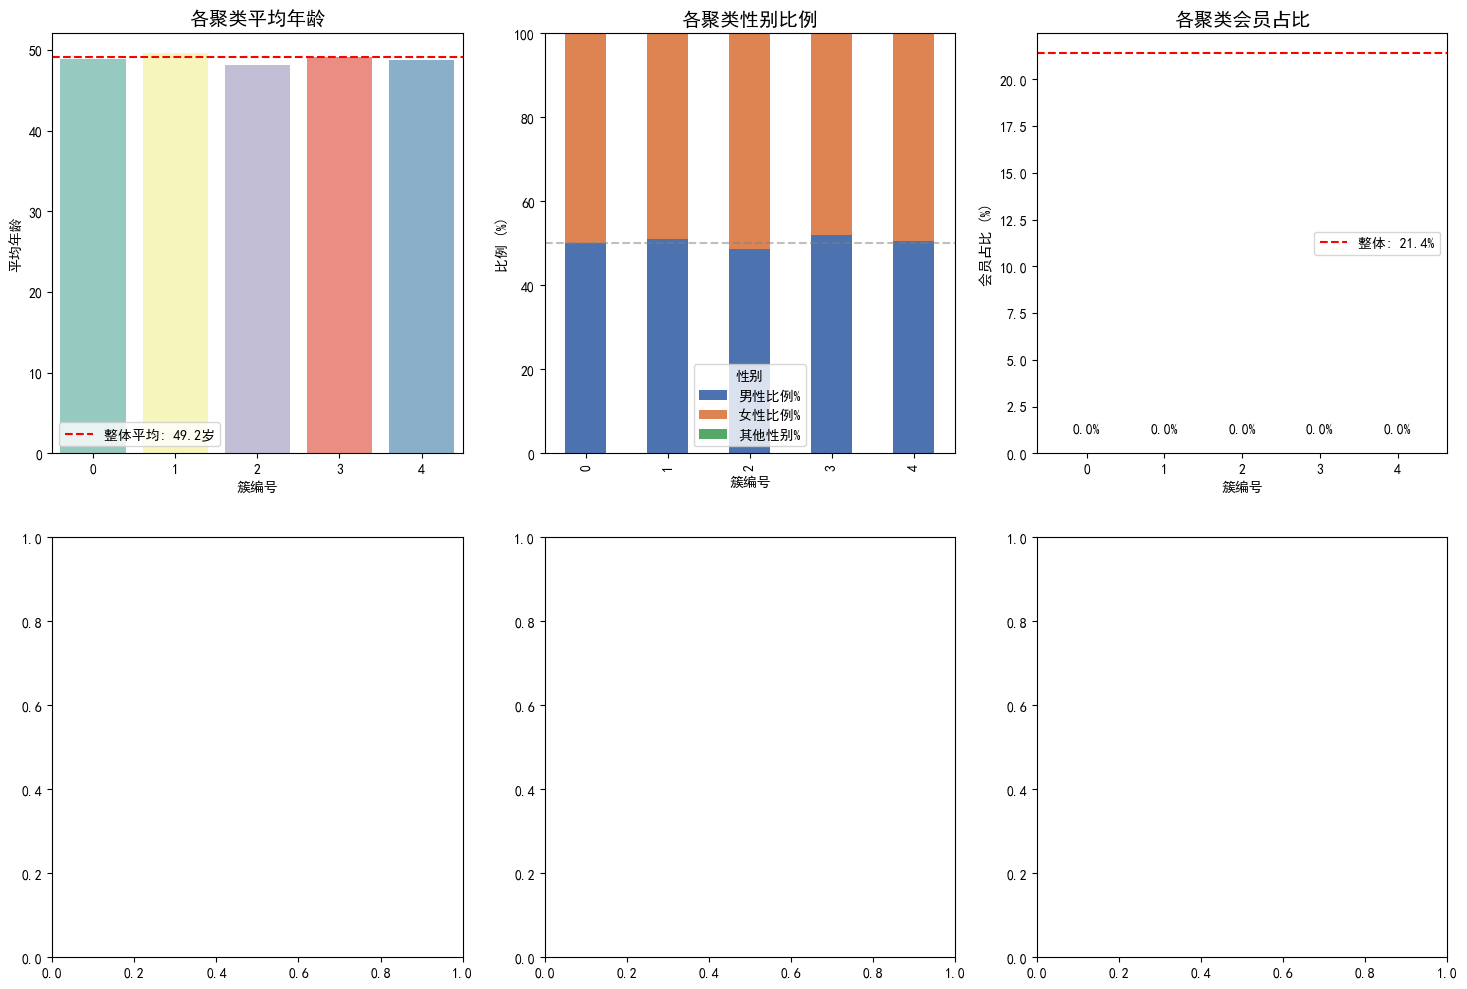

In [39]:
# 13.8 可视化
print("\n" + "="*70)
print("【步骤8：特征可视化】")
print("="*70)

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 创建可视化
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 13.8.1 各簇年龄分布
    ax1 = axes[0, 0]
    sns.barplot(data=full_profile, x='Cluster', y='平均年龄', palette='Set3', ax=ax1)
    ax1.axhline(y=overall_stats['平均年龄'], color='r', linestyle='--', label=f'整体平均: {overall_stats["平均年龄"]}岁')
    ax1.set_title('各聚类平均年龄', fontsize=14, fontweight='bold')
    ax1.set_xlabel('簇编号')
    ax1.set_ylabel('平均年龄')
    ax1.legend()
    
    # 13.8.2 性别比例堆叠图
    ax2 = axes[0, 1]
    gender_data = full_profile[['Cluster', '男性比例%', '女性比例%', '其他性别%']].set_index('Cluster')
    gender_data.plot(kind='bar', stacked=True, ax=ax2, color=['#4C72B0', '#DD8452', '#55A868'])
    ax2.set_title('各聚类性别比例', fontsize=14, fontweight='bold')
    ax2.set_xlabel('簇编号')
    ax2.set_ylabel('比例 (%)')
    ax2.legend(title='性别')
    ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
    
    # 13.8.3 会员占比
    ax3 = axes[0, 2]
    bars = ax3.bar(full_profile['Cluster'], full_profile['会员占比%'], color='skyblue')
    ax3.axhline(y=overall_stats['会员占比%'], color='r', linestyle='--', label=f'整体: {overall_stats["会员占比%"]}%')
    ax3.set_title('各聚类会员占比', fontsize=14, fontweight='bold')
    ax3.set_xlabel('簇编号')
    ax3.set_ylabel('会员占比 (%)')
    ax3.legend()
    
    # 添加数值标签
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%', ha='center', va='bottom')
    
    # 13.8.4 附加购买率
    ax4 = axes[1, 0]
    bars = ax4.bar(full_profile['Cluster'], full_profile['Add-on purchase rate%'], color='lightcoral')
    ax4.axhline(y=overall_stats['Add-on purchase rate%'], color='r', linestyle='--', label=f'整体: {overall_stats["Add-on purchase rate%"]}%')
    ax4.set_title('Add-on Purchase Rates by Cluster', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Cluster Number')
    ax4.set_ylabel('Add-on Purchase Rate (%)')
    ax4.legend()
    
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%', ha='center', va='bottom')
    
    # 13.8.5 客户规模分布
    ax5 = axes[1, 1]
    wedges, texts, autotexts = ax5.pie(full_profile['客户数量'], 
                                        labels=[f'簇{int(c)}' for c in full_profile['Cluster']],
                                        autopct='%1.1f%%',
                                        colors=plt.cm.Set3(range(len(full_profile))))
    ax5.set_title('各聚类客户规模分布', fontsize=14, fontweight='bold')
    
    # 13.8.6 特征雷达图（简化版）
    ax6 = axes[1, 2]
    
    # 准备雷达图数据（归一化）
    radar_features = ['会员占比%', '附加购买率%']
    if 'M_Monetary' in full_profile.columns:
        radar_features = ['会员占比%', '附加购买率%', 'M_Monetary']
        # 归一化M值
        full_profile['M_norm'] = full_profile['M_Monetary'] / full_profile['M_Monetary'].max() * 100
    
    # 选择前3个簇绘制雷达图（避免太拥挤）
    top3_clusters = full_profile.nlargest(3, '客户数量')['Cluster'].values
    
    # 设置雷达图角度
    categories = radar_features
    N = len(categories)
    angles = [n / float(N) * 2 * 3.14159 for n in range(N)]
    angles += angles[:1]
    
    # 绘制雷达图
    for cluster in top3_clusters:
        cluster_row = full_profile[full_profile['Cluster'] == cluster].iloc[0]
        values = [cluster_row['会员占比%'], cluster_row['附加购买率%']]
        if 'M_norm' in full_profile.columns:
            values = [cluster_row['会员占比%'], cluster_row['附加购买率%'], cluster_row['M_norm']]
        values += values[:1]
        
        ax6.plot(angles, values, 'o-', linewidth=2, label=f'簇{int(cluster)}')
        ax6.fill(angles, values, alpha=0.1)
    
    ax6.set_xticks(angles[:-1])
    ax6.set_xticklabels(categories)
    ax6.set_title('主要聚类特征对比', fontsize=14, fontweight='bold')
    ax6.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    
    plt.suptitle('聚类人口统计与附加购买特征分析', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('cluster_demographic_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ 特征可视化图已保存为 'cluster_demographic_analysis.png'")
    
except ImportError as e:
    print(f"⚠️ 可视化库未安装，跳过图表生成：{e}")
except Exception as e:
    print(f"⚠️ 生成可视化图表时出错：{e}")

# 13.9 最终总结
print("\n" + "="*70)
print("【聚类分析最终总结】")
print("="*70)

print(f"""
📊 分析完成！共 {len(full_profile)} 个聚类

关键发现摘要：
""")

for _, row in full_profile.iterrows():
    cluster = int(row['Cluster'])
    
    # 构建特征标签
    tags = []
    
    # 年龄标签
    if row['平均年龄'] > overall_stats['平均年龄'] + 2:
        tags.append("年长型")
    elif row['平均年龄'] < overall_stats['平均年龄'] - 2:
        tags.append("年轻型")
    
    # 性别标签
    if row['男性比例%'] > 60:
        tags.append("男性主导")
    elif row['女性比例%'] > 60:
        tags.append("女性主导")
    
    # 会员标签
    if row['会员占比%'] > overall_stats['会员占比%'] + 5:
        tags.append("高忠诚度")
    elif row['会员占比%'] < overall_stats['会员占比%'] - 5:
        tags.append("低忠诚度")
    
    # 附加购买标签
    if row['附加购买率%'] > overall_stats['附加购买率%'] + 5:
        tags.append("易交叉销售")
    
    # RFM标签（如果有）
    if 'M_Monetary' in row:
        if row['M_Monetary'] > full_profile['M_Monetary'].mean() * 1.2:
            tags.append("高价值")
        elif row['M_Monetary'] < full_profile['M_Monetary'].mean() * 0.8:
            tags.append("低价值")
    
    tag_str = " · ".join(tags) if tags else "普通型"
    
    print(f"  簇{cluster}: {tag_str} - {row['客户数量']} 客户 ({row['占比%']:.1f}%)")

print("\n✅ 聚类深度分析完成！")